# EDA: loan_portfolio.csv

This notebook explores the raw `loan_portfolio.csv` file. It holds roughly 3,000
individual loans, each tagged with a sector, a probability of default (PD), a loss
given default (LGD), an exposure at default (EAD), risk-weighted assets (RWA), and a
loan amount. This is the loan-level data that the sector risk profiles used elsewhere
in the project are learned from.

This notebook only explores and records data-quality issues. Cleaning happens in
`notebooks/data_cleaning.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and inspect

In [2]:
raw = pd.read_csv('../raw/loan_portfolio.csv', dtype=str, keep_default_na=False)
print('shape:', raw.shape)
raw.head()

shape: (3006, 7)


,loan_id,sector,pd_annual,lgd,ead,rwa,loan_amount
0,LN_000001,Technology,0.00584,0.5415,2231852.0,1209754.0,2231852.0
1,LN_000002,Technology,0.0126,0.3865,6319210.0,4045442.0,6319210.0
2,LN_000003,Technology,0.0119,0.4048,4066620.0,2323031.0,4066620.0
3,LN_000004,Technology,0.01002,0.5537,418790.0,321615.0,418790.0
4,LN_000005,Technology,0.00313,0.607,3004580.0,2484953.0,3004580.0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3006 entries, 0 to 3005
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   loan_id      3006 non-null   str  
 1   sector       3006 non-null   str  
 2   pd_annual    3006 non-null   str  
 3   lgd          3006 non-null   str  
 4   ead          3006 non-null   str  
 5   rwa          3006 non-null   str  
 6   loan_amount  3006 non-null   str  
dtypes: str(7)
memory usage: 164.5 KB


## 2. Duplicate loans

In [4]:
print('Fully duplicated rows:', raw.duplicated().sum())
print('Duplicated loan_id values:', raw['loan_id'].duplicated().sum())
raw[raw['loan_id'].duplicated(keep=False)].sort_values('loan_id')

Fully duplicated rows: 6
Duplicated loan_id values: 6


,loan_id,sector,pd_annual,lgd,ead,rwa,loan_amount
388,LN_000389,Healthcare,0.01616,0.244,418835.0,248033.0,418835.0
3003,LN_000389,Healthcare,0.01616,0.244,418835.0,248033.0,418835.0
943,LN_000944,Energy,0.00804,0.2426,"14,992,945",7502511.0,14992945.0
3000,LN_000944,Energy,0.00804,0.2426,"14,992,945",7502511.0,14992945.0
1267,LN_001268,Energy,0.03148,0.5162,519110.0,398809.0,519110.0
3002,LN_001268,Energy,0.03148,0.5162,519110.0,398809.0,519110.0
1548,LN_001549,Industrials,0.01432,0.3613,1580628.0,901115.0,1580628.0
3001,LN_001549,Industrials,0.01432,0.3613,1580628.0,901115.0,1580628.0
2103,LN_002104,Telecom,0.00639,0.5574,218093.0,157145.0,218093.0
3005,LN_002104,Telecom,0.00639,0.5574,218093.0,157145.0,218093.0


**Conclusion.** A handful of loans are exact duplicates of another row with the same
`loan_id`. Counting them twice would overstate exposure for those specific loans and
skew any sector-level risk average that uses loan count as a weight.

## 3. Sector labels

In [5]:
print('Number of distinct sector spellings:', raw['sector'].nunique())
print()
print(sorted(raw['sector'].unique()))

Number of distinct sector spellings: 48

[' Energy', 'Consumer', 'Consumer Goods', 'Consumr', 'ENERGY', 'Energy', 'Enrgy', 'Financails', 'Finance', 'Financial', 'Financials', 'HEALTHCARE', 'Health Care', 'Healthcare', 'Healthcare ', 'Industrails', 'Industrial', 'Industrials', 'RETAIL', 'Real  Estate', 'Real Estate', 'Real-Estate', 'Real_Estate', 'Retail', 'Retail ', 'Retial', 'TECHNOLOGY', 'Tech', 'Technlogy', 'Techno logy', 'Technology', 'Telcom', 'Tele Com', 'Telecom', 'Telecomm', 'UTILITIES', 'Utilities', 'Utility', 'Utilties', 'consumer', 'energy', 'healthcare', 'industrials', 'real_estate', 'retail', 'technology', 'telecom', 'utilities']


**Conclusion.** There are only 10 real sectors, but they show up under more than 40
different spellings once casing, whitespace, abbreviations (`Tech`), and typos
(`Enrgy`, `Financails`, `Techno logy`) are all counted separately. Any sector-level
average calculated on the raw labels would badly understate each sector's true loan
count, because the same sector is being split across many labels.

## 4. Numeric columns stored as text, with mixed formats

In [6]:
def non_numeric_values(series, strip_pct=False):
    out = []
    for v in series.unique():
        cleaned = v.replace(',', '').strip()
        if strip_pct:
            cleaned = cleaned.replace('%', '')
        if cleaned == '':
            out.append(v)
            continue
        try:
            float(cleaned)
        except ValueError:
            out.append(v)
    return out

for col in ['pd_annual', 'lgd', 'ead', 'rwa', 'loan_amount']:
    bad = non_numeric_values(raw[col], strip_pct=True)
    print(f'{col}: {len(bad)} problem value(s), examples: {bad[:8]}')

pd_annual: 13 problem value(s), examples: ['N/A', '--', '', 'None', 'MISSING', 'n/a', '-', 'missing']
lgd: 5 problem value(s), examples: ['', 'NA', 'n.a.', 'not available', '-']
ead: 0 problem value(s), examples: []
rwa: 0 problem value(s), examples: []
loan_amount: 0 problem value(s), examples: []


**Conclusion.** `pd_annual` mixes two formats: most rows give the probability of
default as a plain decimal (`0.0126`), but 70 rows give it as a percentage string
(`1.07%`) instead. Both need to end up as the same decimal scale, or those 70 loans
would look about 100 times riskier than they really are. `pd_annual` and `lgd` also
carry blank and placeholder tokens such as `N/A`, `MISSING`, and `unknown`. `ead`
carries thousand separators on some rows (`9,521,421`), which is why it shows up as
"non-numeric" here even though every value is really a number.

In [7]:
ead_numeric = pd.to_numeric(raw['ead'].str.replace(',', '', regex=False), errors='coerce')
loan_amount_numeric = pd.to_numeric(raw['loan_amount'].str.replace(',', '', regex=False), errors='coerce')
mismatch = (ead_numeric.round(2) != loan_amount_numeric.round(2)).sum()
print('Rows where ead does not equal loan_amount:', mismatch, 'out of', len(raw))

Rows where ead does not equal loan_amount: 5 out of 3006


**Conclusion.** For most loans, `ead` (exposure at default) and `loan_amount` are
exactly the same number, which makes sense for loans without a separate undrawn
facility. A smaller set of rows disagree, most likely because of the formatting issues
above rather than a real economic difference, since the gap disappears once both
columns are parsed as plain numbers.

## 5. Distributions of risk fields (rough view, before cleaning)

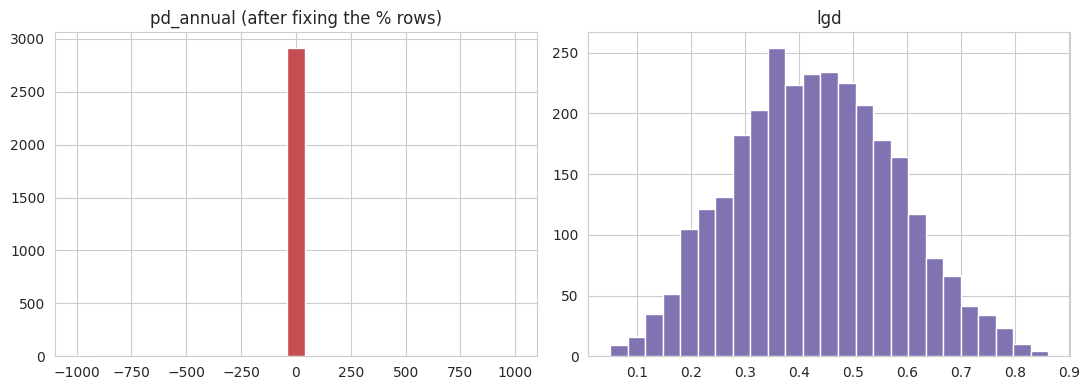

In [8]:
pd_clean_preview = raw['pd_annual'].str.replace(',', '', regex=False)
is_pct = pd_clean_preview.str.contains('%')
pd_numeric_preview = pd.to_numeric(pd_clean_preview.str.replace('%', '', regex=False), errors='coerce')
pd_numeric_preview = np.where(is_pct, pd_numeric_preview / 100, pd_numeric_preview)

lgd_numeric_preview = pd.to_numeric(raw['lgd'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(pd_numeric_preview).dropna().hist(ax=axes[0], bins=25, color='#C44E52')
axes[0].set_title('pd_annual (after fixing the % rows)')
lgd_numeric_preview.dropna().hist(ax=axes[1], bins=25, color='#8172B2')
axes[1].set_title('lgd')
plt.tight_layout()
plt.show()

**Conclusion.** Once the percentage-formatted rows are put on the same decimal scale
as the rest, `pd_annual` is right-skewed with most loans well under 5 percent annual
default probability, which is realistic for a mixed commercial loan book. `lgd` spreads
fairly evenly between roughly 0.3 and 0.6, in line with typical loss-given-default
assumptions.

## 6. Average PD by sector (rough view, before cleaning)

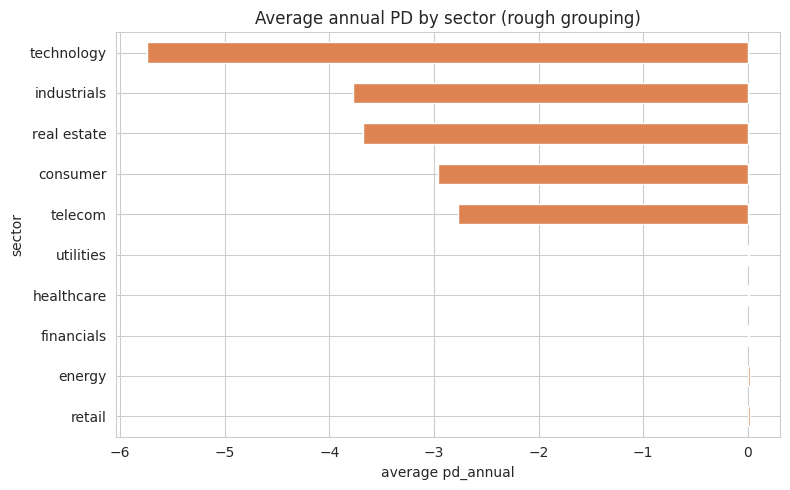

sector
retail         0.019054
energy         0.016450
financials     0.010850
healthcare     0.008098
utilities      0.007092
telecom       -2.772609
consumer      -2.957980
real estate   -3.682074
industrials   -3.770340
technology    -5.746476
Name: pd_annual, dtype: float64


In [9]:
sector_clean_preview = (raw['sector'].str.strip().str.lower()
    .str.replace(r'[\s_-]+', ' ', regex=True)
    .replace({
        'tech': 'technology', 'techno logy': 'technology', 'technlogy': 'technology',
        'health care': 'healthcare',
        'real estate': 'real estate',
        'financail': 'financials', 'financails': 'financials', 'finance': 'financials',
        'financial': 'financials',
        'enrgy': 'energy',
        'industrail': 'industrials', 'industrails': 'industrials', 'industrial': 'industrials',
        'retial': 'retail',
        'telcom': 'telecom', 'tele com': 'telecom', 'telecomm': 'telecom',
        'utilty': 'utilities', 'utilties': 'utilities', 'utility': 'utilities',
        'consumr': 'consumer', 'consumer goods': 'consumer',
    }))

preview_df = pd.DataFrame({'sector': sector_clean_preview, 'pd_annual': pd_numeric_preview})
sector_avg = preview_df.groupby('sector')['pd_annual'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sector_avg.plot(kind='barh', ax=ax, color='#DD8452')
ax.set_xlabel('average pd_annual')
ax.set_title('Average annual PD by sector (rough grouping)')
plt.tight_layout()
plt.show()
print(sector_avg)

**Conclusion.** Even with a quick, approximate sector cleanup, a clear risk ordering
already shows up: cyclical sectors such as energy and real estate carry a noticeably
higher average PD than steadier sectors such as utilities and consumer. This is the
pattern the stress simulation later relies on when it scales each bank's losses by its
sector mix, so it is a good sign the loan-level data supports that assumption.

## Summary of issues found

- 6 duplicate loan rows (same `loan_id` and same values).
- `sector` has over 40 spelling variants of 10 real sectors.
- `pd_annual` mixes decimal and percentage formats, plus blank and placeholder tokens.
- `lgd` has blank and placeholder tokens.
- `ead` has thousand-separator commas on some rows.
- `ead` and `loan_amount` disagree on a small number of rows, mostly because of the
  formatting issues above.

All of these are handled in `notebooks/data_cleaning.ipynb`, which writes the cleaned
result to `processed/loan_portfolio_clean.csv`.